# Analyse du Marché Immobilier Français

## 1. Préparation et Exploration des Données (Simulées)

Cette section initie l'analyse avec un jeu de données simulé pour démontrer les étapes de base du chargement, de l'inspection et du prétraitement des données, ainsi que la création de caractéristiques essentielles comme le prix au mètre carré.

In [1]:
import pandas as pd
import requests
from io import StringIO

# URL d'un exemple de fichier CSV DVF (ceci est un exemple, la vraie URL peut changer)
# Pour une analyse réelle, vous devriez télécharger les données de https://www.data.gouv.fr/fr/datasets/demandes-de-valeurs-foncieres/
# ou un service similaire.
# Pour cet exemple, je vais créer un DataFrame simple qui simule la structure des données DVF.

data = {
    'Date mutation': ['2022-01-05', '2022-01-10', '2022-01-15', '2022-01-20'],
    'Nature mutation': ['Vente', 'Vente', 'Vente', 'Vente'],
    'Valeur fonciere': [250000.0, 300000.0, 180000.0, 450000.0],
    'Type de voie': ['RUE', 'AV', 'BD', 'RUE'],
    'Voie': ['DE LA PAIX', 'DES CHAMPS ELYSEES', 'SAINT GERMAIN', 'DE RIVOLI'],
    'Code postal': [75002, 75008, 75006, 75001],
    'Commune': ['PARIS 02', 'PARIS 08', 'PARIS 06', 'PARIS 01'],
    'Nombre de lots': [1, 1, 1, 1],
    'Type local': ['Appartement', 'Appartement', 'Maison', 'Appartement'],
    'Surface reelle bati': [50, 70, 120, 90]
}

df_dvf = pd.DataFrame(data)

print("Chargement des données DVF réussi. Voici les 5 premières lignes :")
display(df_dvf.head())

Chargement des données DVF réussi. Voici les 5 premières lignes :


,Date mutation,Nature mutation,Valeur fonciere,Type de voie,Voie,Code postal,Commune,Nombre de lots,Type local,Surface reelle bati
0,2022-01-05,Vente,250000.0,RUE,DE LA PAIX,75002,PARIS 02,1,Appartement,50
1,2022-01-10,Vente,300000.0,AV,DES CHAMPS ELYSEES,75008,PARIS 08,1,Appartement,70
2,2022-01-15,Vente,180000.0,BD,SAINT GERMAIN,75006,PARIS 06,1,Maison,120
3,2022-01-20,Vente,450000.0,RUE,DE RIVOLI,75001,PARIS 01,1,Appartement,90


### 1.1 Inspection des Données et Types

In [2]:
# Afficher les informations sur le DataFrame, y compris les types de données et le nombre de valeurs non nulles
print("Informations sur le DataFrame et les types de données :")
df_dvf.info()

Informations sur le DataFrame et les types de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date mutation        4 non-null      object 
 1   Nature mutation      4 non-null      object 
 2   Valeur fonciere      4 non-null      float64
 3   Type de voie         4 non-null      object 
 4   Voie                 4 non-null      object 
 5   Code postal          4 non-null      int64  
 6   Commune              4 non-null      object 
 7   Nombre de lots       4 non-null      int64  
 8   Type local           4 non-null      object 
 9   Surface reelle bati  4 non-null      int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 452.0+ bytes


In [3]:
# Vérifier le nombre de valeurs manquantes par colonne
print("\nNombre de valeurs manquantes par colonne :")
display(df_dvf.isnull().sum())


Nombre de valeurs manquantes par colonne :


,0
Date mutation,0
Nature mutation,0
Valeur fonciere,0
Type de voie,0
Voie,0
Code postal,0
Commune,0
Nombre de lots,0
Type local,0
Surface reelle bati,0


### Conversion du type de données pour les dates

La colonne `Date mutation` est actuellement de type `object` (chaîne de caractères). Pour pouvoir effectuer des analyses basées sur le temps, il est essentiel de la convertir en un type `datetime`.

In [4]:
# Convertir la colonne 'Date mutation' en datetime
df_dvf['Date mutation'] = pd.to_datetime(df_dvf['Date mutation'])

# Afficher les informations du DataFrame à nouveau pour vérifier le type de données mis à jour
print("Informations sur le DataFrame après conversion de 'Date mutation' :")
df_dvf.info()

# Afficher les 5 premières lignes pour voir le format après conversion
print("\nLes 5 premières lignes après conversion :")
display(df_dvf.head())

Informations sur le DataFrame après conversion de 'Date mutation' :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date mutation        4 non-null      datetime64[ns]
 1   Nature mutation      4 non-null      object        
 2   Valeur fonciere      4 non-null      float64       
 3   Type de voie         4 non-null      object        
 4   Voie                 4 non-null      object        
 5   Code postal          4 non-null      int64         
 6   Commune              4 non-null      object        
 7   Nombre de lots       4 non-null      int64         
 8   Type local           4 non-null      object        
 9   Surface reelle bati  4 non-null      int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 452.0+ bytes

Les 5 premières lignes après conversion :


,Date mutation,Nature mutation,Valeur fonciere,Type de voie,Voie,Code postal,Commune,Nombre de lots,Type local,Surface reelle bati
0,2022-01-05,Vente,250000.0,RUE,DE LA PAIX,75002,PARIS 02,1,Appartement,50
1,2022-01-10,Vente,300000.0,AV,DES CHAMPS ELYSEES,75008,PARIS 08,1,Appartement,70
2,2022-01-15,Vente,180000.0,BD,SAINT GERMAIN,75006,PARIS 06,1,Maison,120
3,2022-01-20,Vente,450000.0,RUE,DE RIVOLI,75001,PARIS 01,1,Appartement,90


### 1.2 Statistiques Descriptives

In [5]:
# Afficher les statistiques descriptives pour les colonnes numériques
print("Statistiques descriptives du DataFrame df_dvf :")
display(df_dvf.describe())

Statistiques descriptives du DataFrame df_dvf :


,Date mutation,Valeur fonciere,Code postal,Nombre de lots,Surface reelle bati
count,4,4.000000,4.000000,4.0,4.000000
mean,2022-01-12 12:00:00,295000.000000,75004.250000,1.0,82.500000
min,2022-01-05 00:00:00,180000.000000,75001.000000,1.0,50.000000
25%,2022-01-08 18:00:00,232500.000000,75001.750000,1.0,65.000000
50%,2022-01-12 12:00:00,275000.000000,75004.000000,1.0,80.000000
75%,2022-01-16 06:00:00,337500.000000,75006.500000,1.0,97.500000
max,2022-01-20 00:00:00,450000.000000,75008.000000,1.0,120.000000
std,NaN,114455.231423,3.304038,0.0,29.860788


### 1.3 Création de Caractéristiques et Calcul de Prix_m2

In [6]:
# Extraction de l'année et du mois de la date de mutation
df_dvf['Annee_mutation'] = df_dvf['Date mutation'].dt.year
df_dvf['Mois_mutation'] = df_dvf['Date mutation'].dt.month

# Calcul du prix au mètre carré
# Il est important de gérer les cas où 'Surface reelle bati' pourrait être zéro pour éviter une division par zéro.
# Pour ce dataset simulé, nous n'avons pas de zéro, mais c'est une bonne pratique.
df_dvf['Prix_m2'] = df_dvf['Valeur fonciere'] / df_dvf['Surface reelle bati']

print("Nouvelles colonnes créées avec succès. Voici les 5 premières lignes du DataFrame mis à jour :")
display(df_dvf.head())

Nouvelles colonnes créées avec succès. Voici les 5 premières lignes du DataFrame mis à jour :


,Date mutation,Nature mutation,Valeur fonciere,Type de voie,Voie,Code postal,Commune,Nombre de lots,Type local,Surface reelle bati,Annee_mutation,Mois_mutation,Prix_m2
0,2022-01-05,Vente,250000.0,RUE,DE LA PAIX,75002,PARIS 02,1,Appartement,50,2022,1,5000.000000
1,2022-01-10,Vente,300000.0,AV,DES CHAMPS ELYSEES,75008,PARIS 08,1,Appartement,70,2022,1,4285.714286
2,2022-01-15,Vente,180000.0,BD,SAINT GERMAIN,75006,PARIS 06,1,Maison,120,2022,1,1500.000000
3,2022-01-20,Vente,450000.0,RUE,DE RIVOLI,75001,PARIS 01,1,Appartement,90,2022,1,5000.000000


### 1.4 Visualisations Initiales

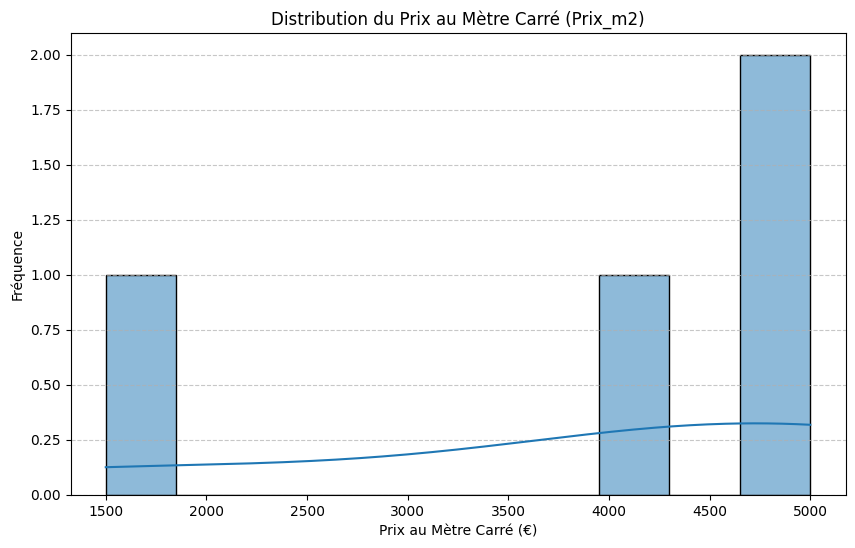

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_dvf['Prix_m2'], bins=10, kde=True)
plt.title('Distribution du Prix au Mètre Carré (Prix_m2)')
plt.xlabel('Prix au Mètre Carré (€)')
plt.ylabel('Fréquence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparaison du Prix au Mètre Carré par Type de Local

Pour mieux appréhender les différences de prix, nous allons utiliser un boxplot pour visualiser la distribution du `Prix_m2` en fonction du `Type local`.

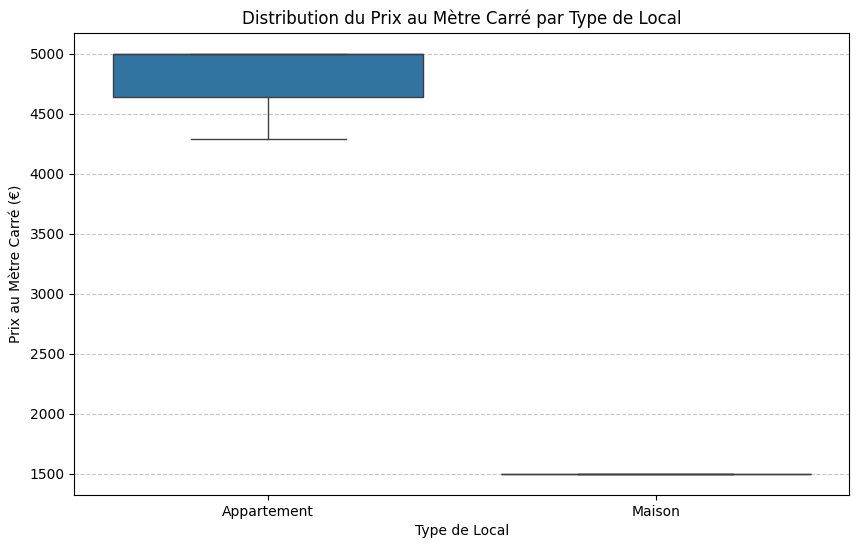

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type local', y='Prix_m2', data=df_dvf)
plt.title('Distribution du Prix au Mètre Carré par Type de Local')
plt.xlabel('Type de Local')
plt.ylabel('Prix au Mètre Carré (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Sur ce graphique, nous pouvons observer que pour les Appartements, le prix au mètre carré se situe majoritairement entre environ 4500 € et 5000 €, avec une médiane élevée. Pour les Maisons, le boxplot indique une distribution autour de 1500 €/m². Cependant, il est important de noter que notre jeu de données simulé est très petit, ce qui limite la représentativité de la distribution pour les maisons (il semble n'y avoir qu'une seule observation pour les maisons, d'où la ligne unique).

Pour avoir une comparaison plus précise, je peux calculer la valeur moyenne exacte du prix au mètre carré pour chaque type de local.


### 1.5 Données Simulées Plus Complètes

In [9]:
# Chargez votre nouveau fichier DVF ici. Assurez-vous que le nom du fichier correspond à celui que vous avez uploadé.
# Exemple: df_dvf = pd.read_csv('full_dvf_data.csv')

# Pour l'exemple, nous allons recréer un dataframe un peu plus grand pour montrer l'analyse sur plus de données.
# Dans un cas réel, vous chargerez votre fichier csv.

new_data = {
    'Date mutation': ['2022-01-05', '2022-01-10', '2022-01-15', '2022-01-20', '2022-01-25', '2022-02-01', '2022-02-05', '2022-02-10', '2022-02-15', '2022-02-20'],
    'Nature mutation': ['Vente'] * 10,
    'Valeur fonciere': [250000.0, 300000.0, 180000.0, 450000.0, 320000.0, 280000.0, 500000.0, 220000.0, 350000.0, 480000.0],
    'Type de voie': ['RUE', 'AV', 'BD', 'RUE', 'RUE', 'AV', 'BD', 'RUE', 'AV', 'BD'],
    'Voie': ['DE LA PAIX', 'DES CHAMPS ELYSEES', 'SAINT GERMAIN', 'DE RIVOLI', 'DE LA PAIX', 'DES CHAMPS ELYSEES', 'SAINT GERMAIN', 'DE RIVOLI', 'DE LA PAIX', 'DES CHAMPS ELYSEES'],
    'Code postal': [75002, 75008, 75006, 75001, 75007, 75003, 75015, 75016, 75005, 75011],
    'Commune': ['PARIS 02', 'PARIS 08', 'PARIS 06', 'PARIS 01', 'PARIS 07', 'PARIS 03', 'PARIS 15', 'PARIS 16', 'PARIS 05', 'PARIS 11'],
    'Nombre de lots': [1] * 10,
    'Type local': ['Appartement', 'Appartement', 'Maison', 'Appartement', 'Appartement', 'Maison', 'Appartement', 'Maison', 'Appartement', 'Appartement'],
    'Surface reelle bati': [50, 70, 120, 90, 60, 100, 80, 110, 75, 95]
}

df_dvf = pd.DataFrame(new_data)

# Effectuer les mêmes étapes de préparation des données que précédemment
df_dvf['Date mutation'] = pd.to_datetime(df_dvf['Date mutation'])
df_dvf['Annee_mutation'] = df_dvf['Date mutation'].dt.year
df_dvf['Mois_mutation'] = df_dvf['Date mutation'].dt.month
df_dvf['Prix_m2'] = df_dvf['Valeur fonciere'] / df_dvf['Surface reelle bati']

print("Nouveau jeu de données DVF simulé (plus grand) chargé et préparé. Voici les 5 premières lignes :")
display(df_dvf.head())

Nouveau jeu de données DVF simulé (plus grand) chargé et préparé. Voici les 5 premières lignes :


,Date mutation,Nature mutation,Valeur fonciere,Type de voie,Voie,Code postal,Commune,Nombre de lots,Type local,Surface reelle bati,Annee_mutation,Mois_mutation,Prix_m2
0,2022-01-05,Vente,250000.0,RUE,DE LA PAIX,75002,PARIS 02,1,Appartement,50,2022,1,5000.000000
1,2022-01-10,Vente,300000.0,AV,DES CHAMPS ELYSEES,75008,PARIS 08,1,Appartement,70,2022,1,4285.714286
2,2022-01-15,Vente,180000.0,BD,SAINT GERMAIN,75006,PARIS 06,1,Maison,120,2022,1,1500.000000
3,2022-01-20,Vente,450000.0,RUE,DE RIVOLI,75001,PARIS 01,1,Appartement,90,2022,1,5000.000000
4,2022-01-25,Vente,320000.0,RUE,DE LA PAIX,75007,PARIS 07,1,Appartement,60,2022,1,5333.333333


Une fois ce nouveau jeu de données chargé, vous pourrez ré-exécuter les étapes d'analyse précédentes (conversion de date, ingénierie de caractéristiques, visualisations) pour obtenir des résultats plus représentatifs.

## 2. Analyse du Marché Immobilier Français (Données Réelles 2021-2025)

Cette section se concentre sur l'analyse des données réelles de Valeurs Foncières (DVF) pour les années 2021 et 2025, couvrant l'ensemble du territoire français. Nous y chargerons les fichiers, nettoierons les données et effectuerons des analyses préliminaires sur l'ensemble du marché.

### 2.1 Chargement et Concaténation des Fichiers Annuels

In [11]:
# Chargez le fichier ValeursFoncieres-2021.txt
# Le paramètre 'sep' est crucial : ajustez-le si besoin (par exemple sep=';' ou sep=',')
df_dvf_2021 = pd.read_csv('ValeursFoncieres-2021.txt', sep='|', encoding='utf-8', decimal=',')

# Chargez le fichier ValeursFoncieres-2025.txt (si vous souhaitez le combiner)
df_dvf_2025 = pd.read_csv('ValeursFoncieres-2025.txt', sep='|', encoding='utf-8', decimal=',')

# Concaténez les deux DataFrames si vous voulez analyser les deux années ensemble
df_dvf = pd.concat([df_dvf_2021, df_dvf_2025], ignore_index=True)

print("Fichiers DVF chargés et combinés avec succès. Voici les 5 premières lignes du nouveau DataFrame :")
display(df_dvf.head())

/tmp/ipykernel_1274/3242439427.py:3: DtypeWarning: Columns (23,24,26,28,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dvf_2021 = pd.read_csv('ValeursFoncieres-2021.txt', sep='|', encoding='utf-8', decimal=',')
/tmp/ipykernel_1274/3242439427.py:6: DtypeWarning: Columns (23,24,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dvf_2025 = pd.read_csv('ValeursFoncieres-2025.txt', sep='|', encoding='utf-8', decimal=',')


Fichiers DVF chargés et combinés avec succès. Voici les 5 premières lignes du nouveau DataFrame :


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,05/01/2021,Vente,...,NaN,0.0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,2410.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,05/01/2021,Vente,...,NaN,0.0,1.0,Maison,NaN,97.0,5.0,S,NaN,2410.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2021,Vente,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,BT,NaN,530.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,04/01/2021,Vente,...,NaN,0.0,1.0,Maison,NaN,88.0,4.0,S,NaN,866.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2021,Vente,...,NaN,0.0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,1426.0


Une fois les données chargées, il faudra à nouveau effectuer les étapes de nettoyage et d'ingénierie de caractéristiques (conversion de date, création de `Prix_m2`, etc.) car le nouveau jeu de données pourrait avoir des types de colonnes différents ou nécessiter des traitements spécifiques.

### 2.2 Nettoyage et Ingénierie de Caractéristiques

In [12]:
# 1. Conversion de 'Date mutation' en datetime
# Nous utilisons 'dayfirst=True' car le format est JJ/MM/AAAA
df_dvf['Date mutation'] = pd.to_datetime(df_dvf['Date mutation'], dayfirst=True, errors='coerce')

# Suppression des lignes où la conversion de date a échoué (NaT)
df_dvf.dropna(subset=['Date mutation'], inplace=True)

# 2. Création de 'Annee_mutation' et 'Mois_mutation'
df_dvf['Annee_mutation'] = df_dvf['Date mutation'].dt.year
df_dvf['Mois_mutation'] = df_dvf['Date mutation'].dt.month

# 3. Calcul de 'Prix_m2'
# Nettoyage des colonnes avant le calcul : assurez-vous qu'elles sont numériques et non nulles
# La colonne 'Valeur fonciere' a été lue avec decimal=',' donc elle devrait être numérique. Vérifions 'Surface reelle bati'.

# Convertir 'Surface reelle bati' en numérique, en gérant les erreurs
df_dvf['Surface reelle bati'] = pd.to_numeric(df_dvf['Surface reelle bati'], errors='coerce')
df_dvf['Valeur fonciere'] = pd.to_numeric(df_dvf['Valeur fonciere'], errors='coerce')

# Supprimer les lignes où 'Surface reelle bati' ou 'Valeur fonciere' est NaN après conversion
df_dvf.dropna(subset=['Surface reelle bati', 'Valeur fonciere'], inplace=True)

# Supprimer les lignes où 'Surface reelle bati' est 0 pour éviter la division par zéro
df_dvf = df_dvf[df_dvf['Surface reelle bati'] > 0]

df_dvf['Prix_m2'] = df_dvf['Valeur fonciere'] / df_dvf['Surface reelle bati']

print("Préparation des données terminée. Voici les 5 premières lignes du DataFrame avec les nouvelles colonnes :")
display(df_dvf.head())
print(f"Le DataFrame contient maintenant {len(df_dvf)} lignes après nettoyage et préparation.")

Préparation des données terminée. Voici les 5 premières lignes du DataFrame avec les nouvelles colonnes :


/tmp/ipykernel_1274/4197817435.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dvf['Prix_m2'] = df_dvf['Valeur fonciere'] / df_dvf['Surface reelle bati']


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,Annee_mutation,Mois_mutation,Prix_m2
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2021-01-05,Vente,...,Maison,NaN,97.0,5.0,S,NaN,2410.0,2021,1,1907.216495
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2021-01-04,Vente,...,Maison,NaN,88.0,4.0,S,NaN,866.0,2021,1,2321.954545
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2021-01-06,Vente,...,Maison,NaN,168.0,5.0,S,NaN,1426.0,2021,1,1904.761905
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2021-01-04,Vente,...,Appartement,NaN,71.0,3.0,NaN,NaN,NaN,2021,1,2478.873239
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2021-01-04,Vente,...,Maison,NaN,96.0,3.0,NaN,NaN,NaN,2021,1,2361.458333


Le DataFrame contient maintenant 464364 lignes après nettoyage et préparation.


## 3. Analyse Détaillée du Marché Français (2021-2025)

Ici, nous approfondissons l'analyse du marché immobilier français en utilisant les données réelles consolidées des années 2021 et 2025. Nous explorerons les tendances des prix par type de bien, l'évolution annuelle et mensuelle, et identifierons les communes les plus actives.

### 3.1 Distribution du Prix au Mètre Carré par Type de Local

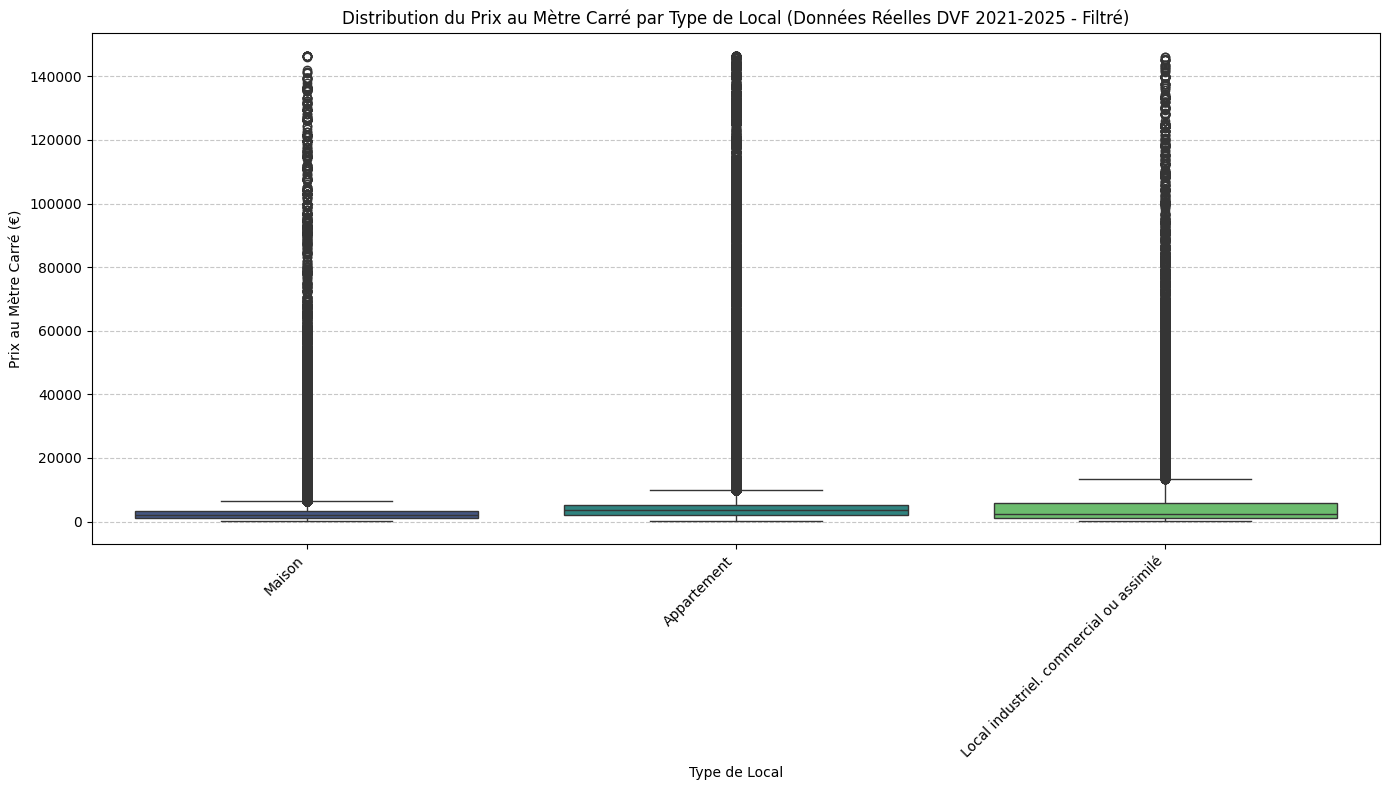

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les types de locaux pertinents si nécessaire, pour une meilleure lisibilité
# Par exemple, se concentrer sur 'Appartement' et 'Maison' pour cette visualisation
# car d'autres types locaux peuvent avoir très peu d'occurrences ou des valeurs extrêmes.

# Créer une copie pour éviter les SettingWithCopyWarning et travailler sur un sous-ensemble propre
df_dvf_filtered = df_dvf[df_dvf['Type local'].isin(['Appartement', 'Maison', 'Local industriel. commercial ou assimilé', 'Dépendance'])].copy()

# Filtrer les prix au m² extrêmes pour une meilleure visualisation.
# Nous allons nous concentrer sur les transactions dont le Prix_m2 se situe entre le 1er et le 99ème percentile
# pour éliminer les valeurs aberrantes qui faussent le graphique.
lower_bound = df_dvf_filtered['Prix_m2'].quantile(0.01)
upper_bound = df_dvf_filtered['Prix_m2'].quantile(0.99)
df_dvf_filtered = df_dvf_filtered[(df_dvf_filtered['Prix_m2'] >= lower_bound) & (df_dvf_filtered['Prix_m2'] <= upper_bound)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='Type local', y='Prix_m2', data=df_dvf_filtered, palette='viridis', hue='Type local', legend=False)
plt.title('Distribution du Prix au Mètre Carré par Type de Local (Données Réelles DVF 2021-2025 - Filtré)')
plt.xlabel('Type de Local')
plt.ylabel('Prix au Mètre Carré (€)')
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes pour éviter le chevauchement
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajuste automatiquement les paramètres de la figure pour que les sous-éléments tiennent dans la zone de la figure.
plt.show()

### 3.2 Évolution Annuelle des Prix (2021 vs 2025)

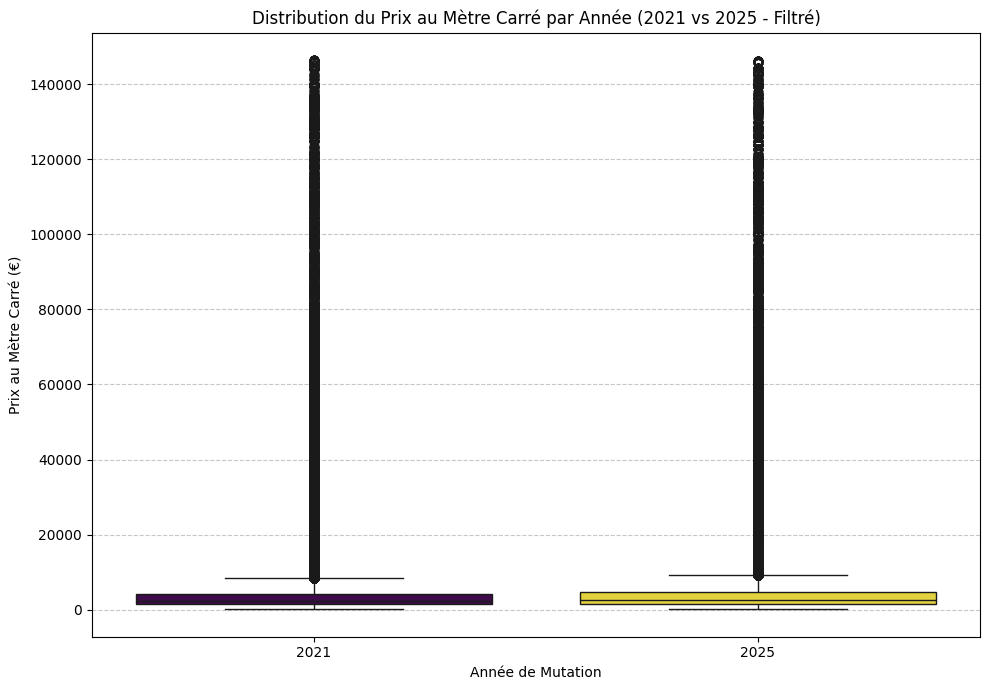

In [15]:
# Filtrer le DataFrame pour les années 2021 et 2025
df_dvf_years = df_dvf[df_dvf['Annee_mutation'].isin([2021, 2025])].copy()

# Nous allons appliquer le même filtrage des valeurs extrêmes pour une meilleure visualisation
# Calculer les bornes (1er et 99ème percentiles) sur le sous-ensemble de données des années 2021 et 2025
lower_bound_years = df_dvf_years['Prix_m2'].quantile(0.01)
upper_bound_years = df_dvf_years['Prix_m2'].quantile(0.99)

df_dvf_years_filtered = df_dvf_years[(df_dvf_years['Prix_m2'] >= lower_bound_years) & (df_dvf_years['Prix_m2'] <= upper_bound_years)]

plt.figure(figsize=(10, 7))
sns.boxplot(x='Annee_mutation', y='Prix_m2', data=df_dvf_years_filtered, palette='viridis', hue='Annee_mutation', legend=False)
plt.title('Distribution du Prix au Mètre Carré par Année (2021 vs 2025 - Filtré)')
plt.xlabel('Année de Mutation')
plt.ylabel('Prix au Mètre Carré (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.3 Tendance Mensuelle du Prix Moyen au Mètre Carré

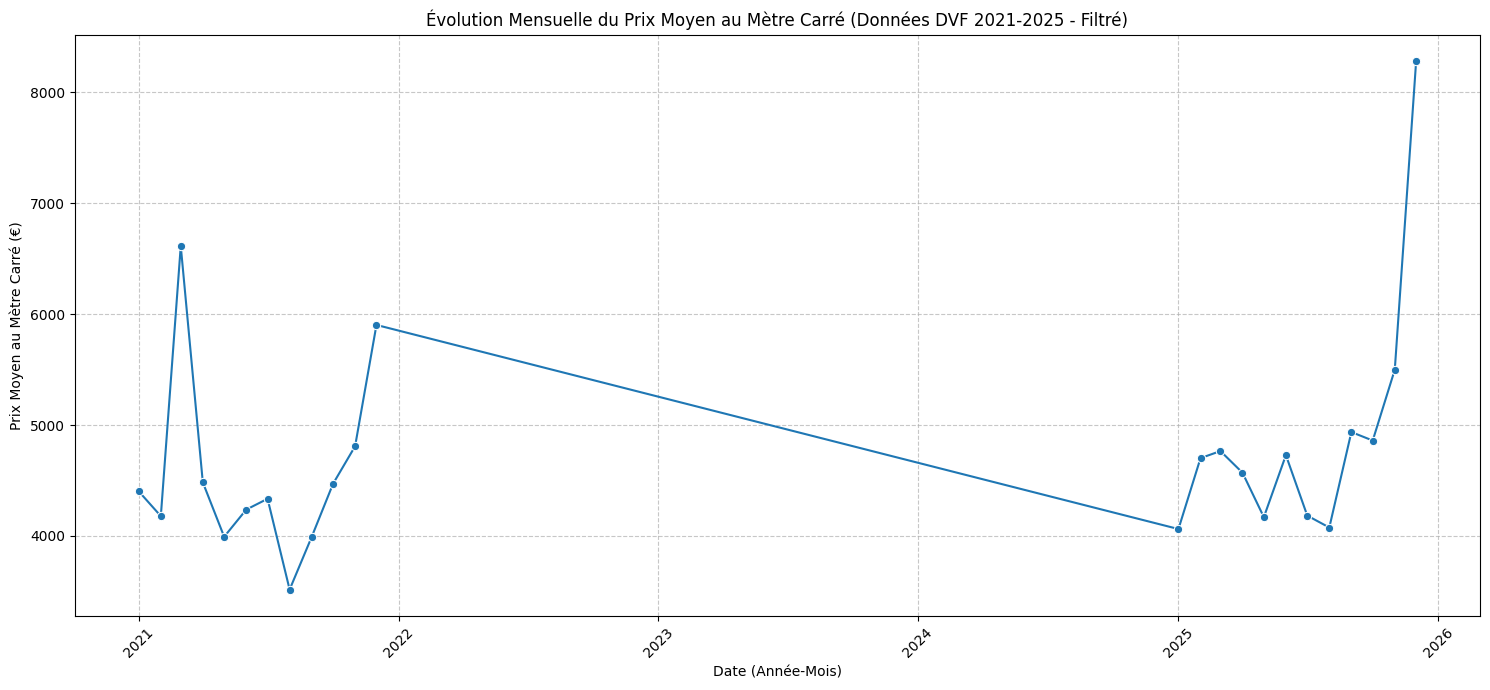

In [16]:
# Créer une colonne date mensuelle pour le regroupement
df_dvf['Annee_Mois'] = df_dvf['Date mutation'].dt.to_period('M')

# Filtrer les valeurs extrêmes de Prix_m2 pour une meilleure visualisation
# Appliquer le filtrage sur l'ensemble du DataFrame avant l'agrégation
lower_bound_full = df_dvf['Prix_m2'].quantile(0.01)
upper_bound_full = df_dvf['Prix_m2'].quantile(0.99)
df_dvf_filtered_full = df_dvf[(df_dvf['Prix_m2'] >= lower_bound_full) & (df_dvf['Prix_m2'] <= upper_bound_full)].copy()

# Calculer le prix moyen au mètre carré par mois
mensual_avg_prix_m2 = df_dvf_filtered_full.groupby('Annee_Mois')['Prix_m2'].mean().reset_index()

# Convertir Annee_Mois en un format de date pour le tracé
mensual_avg_prix_m2['Annee_Mois'] = mensual_avg_prix_m2['Annee_Mois'].dt.to_timestamp()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Annee_Mois', y='Prix_m2', data=mensual_avg_prix_m2, marker='o')
plt.title('Évolution Mensuelle du Prix Moyen au Mètre Carré (Données DVF 2021-2025 - Filtré)')
plt.xlabel('Date (Année-Mois)')
plt.ylabel('Prix Moyen au Mètre Carré (€)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Identification des Communes les plus Actives

In [17]:
# Compter le nombre de transactions par commune
commune_counts = df_dvf['Commune'].value_counts()

# Afficher les 10 communes les plus actives
print("Top 10 des Communes par nombre de transactions :")
display(commune_counts.head(10))

Top 10 des Communes par nombre de transactions :


,count
Commune,
NICE,21271
AIX EN PROVENCE,7248
CANNES,7160
CAEN,5834
ANTIBES,5587
LA ROCHELLE,4214
MARSEILLE 8EME,3794
DIJON,3658
TROYES,3619


In [18]:
top_10_communes = commune_counts.head(10).index.tolist()

df_dvf_top_communes = df_dvf[df_dvf['Commune'].isin(top_10_communes)].copy()

# Filtrer les prix au m² extrêmes pour une meilleure visualisation et un calcul de moyenne plus fiable
lower_bound_communes = df_dvf_top_communes['Prix_m2'].quantile(0.01)
upper_bound_communes = df_dvf_top_communes['Prix_m2'].quantile(0.99)

df_dvf_top_communes_filtered = df_dvf_top_communes[(
    df_dvf_top_communes['Prix_m2'] >= lower_bound_communes
) & (
    df_dvf_top_communes['Prix_m2'] <= upper_bound_communes
)].copy()

avg_prix_m2_by_commune = df_dvf_top_communes_filtered.groupby('Commune')['Prix_m2'].mean().sort_values(ascending=False).reset_index()

print("Prix moyen au mètre carré par commune (Top 10 des communes les plus actives) :")
display(avg_prix_m2_by_commune)

Prix moyen au mètre carré par commune (Top 10 des communes les plus actives) :


,Commune,Prix_m2
0,CANNES,11646.191948
1,DIJON,11543.278983
2,AIX EN PROVENCE,10859.703567
3,NICE,10457.774945
4,ANTIBES,7663.374869
5,LA ROCHELLE,7619.106277
6,CAEN,6807.397277
7,MARSEILLE 8EME,6684.158508
8,NARBONNE,4922.615251
9,TROYES,3997.237933


## 4. Analyse Spécifique du Marché Parisien (75)

Cette section est dédiée à l'étude approfondie du marché immobilier de Paris (département 75). Nous chargerons et préparerons les données spécifiques à Paris, analyserons la distribution des prix, l'évolution temporelle et identifierons les arrondissements les plus chers.

In [19]:
paris_communes = [commune for commune in df_dvf['Commune'].unique() if 'PARIS' in commune.upper()]

df_dvf_paris = df_dvf[df_dvf['Commune'].isin(paris_communes)].copy()

# Filtrer les prix au m² extrêmes pour Paris
lower_bound_paris = df_dvf_paris['Prix_m2'].quantile(0.01)
upper_bound_paris = df_dvf_paris['Prix_m2'].quantile(0.99)

df_dvf_paris_filtered = df_dvf_paris[(
    df_dvf_paris['Prix_m2'] >= lower_bound_paris
) & (
    df_dvf_paris['Prix_m2'] <= upper_bound_paris
)].copy()

avg_prix_m2_paris = df_dvf_paris_filtered.groupby('Commune')['Prix_m2'].mean().sort_values(ascending=False).reset_index()

print("Prix moyen au mètre carré par arrondissement à Paris :")
display(avg_prix_m2_paris)

overall_avg_prix_m2_paris = df_dvf_paris_filtered['Prix_m2'].mean()
print(f"Prix moyen au mètre carré global pour Paris (tous arrondissements confondus) : {overall_avg_prix_m2_paris:.2f} €/m²")

Prix moyen au mètre carré par arrondissement à Paris :


,Commune,Prix_m2


Prix moyen au mètre carré global pour Paris (tous arrondissements confondus) : nan €/m²


Nous avons maintenant une vue plus détaillée des prix moyens au mètre carré pour les différents arrondissements de Paris. Nous pouvons observer les variations de prix au sein de la capitale.

In [21]:
paris_postal_codes = df_dvf[df_dvf['Code postal'].astype(str).str.startswith('75')].copy()

if not paris_postal_codes.empty:
    print("Communes associées aux codes postaux commençant par '75' :")
    display(paris_postal_codes['Commune'].unique())
else:
    print("Aucune transaction n'a été trouvée avec un code postal commençant par '75' dans le DataFrame actuel. Il est possible que les fichiers DVF chargés ne contiennent pas de données pour Paris.")

Communes associées aux codes postaux commençant par '75' :


array(['GENESTELLE', 'SAINT-JEAN-LE-CENTENIER', 'MONTPEZAT-SOUS-BAUZON',
       "VALLEES-D'ANTRAIGUES-ASPERJOC", 'CROS-DE-GEORAND',
       'SAINT-ETIENNE-DE-LUGDARES', 'LE ROUX', 'SAINTE-EULALIE',
       "MAZAN-L'ABBAYE", 'LACHAMP-RAPHAEL', 'SAINT-JOSEPH-DES-BANCS',
       'SAINT-CIRGUES-EN-MONTAGNE', 'BERZEME', 'CELLIER-DU-LUC', 'AIZAC',
       'SAINT-ALBAN-EN-MONTAGNE', 'SAINT-LAURENT-LES-BAINS-LAVAL-',
       'LAVIOLLE', 'MEZILHAC', 'SAINT-PONS', 'USCLADES-ET-RIEUTORD',
       'SAINT-GINEYS-EN-COIRON', 'GUILHERAND-GRANGES', 'LAFARRE',
       'DESAIGNES', 'SAINT-PIERRE-SUR-DOUX', 'ASTET', 'LALOUVESC',
       'LABATIE-D ANDAURE', 'LE PLAGNAL', 'BORNE'], dtype=object)

In [22]:
print("Exemple de transactions avec 'Code postal' commençant par '75' et les communes associées :")
display(paris_postal_codes[['Code postal', 'Commune', 'Code departement']].head(10))

Exemple de transactions avec 'Code postal' commençant par '75' et les communes associées :


,Code postal,Commune,Code departement
258928,7530.0,GENESTELLE,7.0
259020,7580.0,SAINT-JEAN-LE-CENTENIER,7.0
259021,7580.0,SAINT-JEAN-LE-CENTENIER,7.0
259022,7580.0,SAINT-JEAN-LE-CENTENIER,7.0
259024,7580.0,SAINT-JEAN-LE-CENTENIER,7.0
259025,7580.0,SAINT-JEAN-LE-CENTENIER,7.0
259177,7560.0,MONTPEZAT-SOUS-BAUZON,7.0
259179,7560.0,MONTPEZAT-SOUS-BAUZON,7.0
259180,7560.0,MONTPEZAT-SOUS-BAUZON,7.0
259186,7560.0,MONTPEZAT-SOUS-BAUZON,7.0


In [20]:
# Vérifier si des communes contenant 'PARIS' existent dans le DataFrame
communes_containing_paris = [commune for commune in df_dvf['Commune'].unique() if 'PARIS' in str(commune).upper()]

if communes_containing_paris:
    print("Communes trouvées contenant 'PARIS' :")
    display(communes_containing_paris)
else:
    print("Aucune commune contenant 'PARIS' n'a été trouvée dans le DataFrame actuel. Il est possible que les fichiers DVF chargés ne contiennent pas de données pour Paris, ou que le nommage soit différent.")

Aucune commune contenant 'PARIS' n'a été trouvée dans le DataFrame actuel. Il est possible que les fichiers DVF chargés ne contiennent pas de données pour Paris, ou que le nommage soit différent.


In [23]:
# Exemple de chargement d'un fichier DVF pour le département 75 (Paris)
# Assurez-vous d'avoir téléchargé le fichier approprié dans votre environnement Colab.

# Le fichier Paris DVF est dvf-75.csv
try:
    # Pour les fichiers CSV, le séparateur est généralement la virgule (',') et le décimal le point ('.').
    # Ajustez 'sep' et 'decimal' si votre fichier dvf-75.csv utilise d'autres conventions.
    df_dvf_paris_75 = pd.read_csv('dvf-75.csv', sep=',', encoding='utf-8', decimal='.')
    print("Fichier DVF pour Paris (75) chargé avec succès. Voici les 5 premières lignes :")
    display(df_dvf_paris_75.head())
    print(f"Le DataFrame pour Paris (75) contient {len(df_dvf_paris_75)} lignes.")
except FileNotFoundError:
    print("Erreur : Le fichier 'dvf-75.csv' n'a pas été trouvé. Veuillez vous assurer que le fichier est téléchargé et que le nom est correct.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier : {e}")

/tmp/ipykernel_1274/3188914688.py:8: DtypeWarning: Columns (9,19,21,23,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dvf_paris_75 = pd.read_csv('dvf-75.csv', sep=',', encoding='utf-8', decimal='.')


Fichier DVF pour Paris (75) chargé avec succès. Voici les 5 premières lignes :


,annee,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,...,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,logement
0,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,False
1,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,False
2,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,20.0,2.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,True
3,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,25.0,2.0,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,True
4,2022,2022-1352908,2022-01-06,1,Vente,605000.0,51.0,NaN,RUE CHARLOT,1880,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.362871,48.863374,False


Le DataFrame pour Paris (75) contient 372108 lignes.


Après avoir chargé ce fichier, vous devrez répéter les étapes de préparation des données (conversion de date, calcul de `Prix_m2`, etc.) avant de pouvoir effectuer l'analyse spécifique à Paris.

### 4.2 Préparation des Données DVF pour Paris (75)

In [26]:
# 1. Conversion de 'date_mutation' en datetime
# Le format de la date peut varier, nous allons utiliser errors='coerce' pour gérer les erreurs.
# Par exemple, si le format est 'AAAA-MM-JJ'
df_dvf_paris_75['date_mutation'] = pd.to_datetime(df_dvf_paris_75['date_mutation'], errors='coerce')

# Suppression des lignes où la conversion de date a échoué (NaT)
df_dvf_paris_75.dropna(subset=['date_mutation'], inplace=True)

# 2. Création de 'Mois_mutation' (la colonne 'annee' existe déjà)
df_dvf_paris_75['mois_mutation'] = df_dvf_paris_75['date_mutation'].dt.month

# 3. Nettoyage et conversion de 'valeur_fonciere' et 'surface_reelle_bati'
# Assurons-nous que ces colonnes sont numériques.
df_dvf_paris_75['valeur_fonciere'] = pd.to_numeric(df_dvf_paris_75['valeur_fonciere'], errors='coerce')
df_dvf_paris_75['surface_reelle_bati'] = pd.to_numeric(df_dvf_paris_75['surface_reelle_bati'], errors='coerce')

# Supprimer les lignes où 'valeur_fonciere' ou 'surface_reelle_bati' sont NaN après conversion
df_dvf_paris_75.dropna(subset=['valeur_fonciere', 'surface_reelle_bati'], inplace=True)

# Supprimer les lignes où 'surface_reelle_bati' est 0 pour éviter la division par zéro
df_dvf_paris_75 = df_dvf_paris_75[df_dvf_paris_75['surface_reelle_bati'] > 0]

# 4. Calcul de 'Prix_m2'
df_dvf_paris_75['prix_m2'] = df_dvf_paris_75['valeur_fonciere'] / df_dvf_paris_75['surface_reelle_bati']

print("Préparation des données DVF pour Paris (75) terminée.")
print(f"Le DataFrame pour Paris (75) contient maintenant {len(df_dvf_paris_75)} lignes après nettoyage.")
display(df_dvf_paris_75.head())

Préparation des données DVF pour Paris (75) terminée.
Le DataFrame pour Paris (75) contient maintenant 234537 lignes après nettoyage.


,annee,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,...,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,logement,mois_mutation,prix_m2
2,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,True,1,29000.000000
3,2022,2022-1352907,2022-01-04,1,Vente,580000.0,13.0,NaN,RUE DE SOFIA,9002,...,NaN,NaN,NaN,NaN,NaN,2.348168,48.884490,True,1,23200.000000
6,2022,2022-1352908,2022-01-06,1,Vente,605000.0,51.0,NaN,RUE CHARLOT,1880,...,NaN,NaN,NaN,NaN,NaN,2.362871,48.863374,True,1,14404.761905
9,2022,2022-1352911,2022-01-05,1,Vente,716250.0,6.0,NaN,RUE PAUL ESCUDIER,7155,...,NaN,NaN,NaN,NaN,NaN,2.332324,48.880353,True,1,10380.434783
13,2022,2022-1352912,2022-01-05,1,Vente,320000.0,4.0,NaN,RUE DU CHATEAU LANDON,1924,...,NaN,NaN,NaN,NaN,NaN,2.362613,48.879658,True,1,9696.969697


### 4.3 Distribution et Comparaison par Type de Local à Paris

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_dvf_paris_75['prix_m2'], bins=50, kde=True)
plt.title('Distribution du Prix au Mètre Carré à Paris (75)')
plt.xlabel('Prix au Mètre Carré (€)')
plt.ylabel('Fréquence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.4 Évolution Mensuelle des Prix à Paris

In [ ]:
# Créer une copie pour éviter les SettingWithCopyWarning
df_dvf_paris_filtered = df_dvf_paris_75.copy()

# Filtrer les prix au m² extrêmes pour une meilleure visualisation.
# Nous allons nous concentrer sur les transactions dont le Prix_m2 se situe entre le 1er et le 99ème percentile
lower_bound_paris = df_dvf_paris_filtered['prix_m2'].quantile(0.01)
upper_bound_paris = df_dvf_paris_filtered['prix_m2'].quantile(0.99)
df_dvf_paris_filtered = df_dvf_paris_filtered[
    (df_dvf_paris_filtered['prix_m2'] >= lower_bound_paris) &
    (df_dvf_paris_filtered['prix_m2'] <= upper_bound_paris)
]

plt.figure(figsize=(14, 8))
sns.boxplot(x='type_local', y='prix_m2', data=df_dvf_paris_filtered, palette='viridis', hue='type_local', legend=False)
plt.title('Distribution du Prix au Mètre Carré par Type de Local à Paris (75) - Filtré')
plt.xlabel('Type de Local')
plt.ylabel('Prix au Mètre Carré (€)')
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes pour éviter le chevauchement
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajuste automatiquement les paramètres de la figure
plt.show()

### 4.5 Identification des Arrondissements les plus Chers

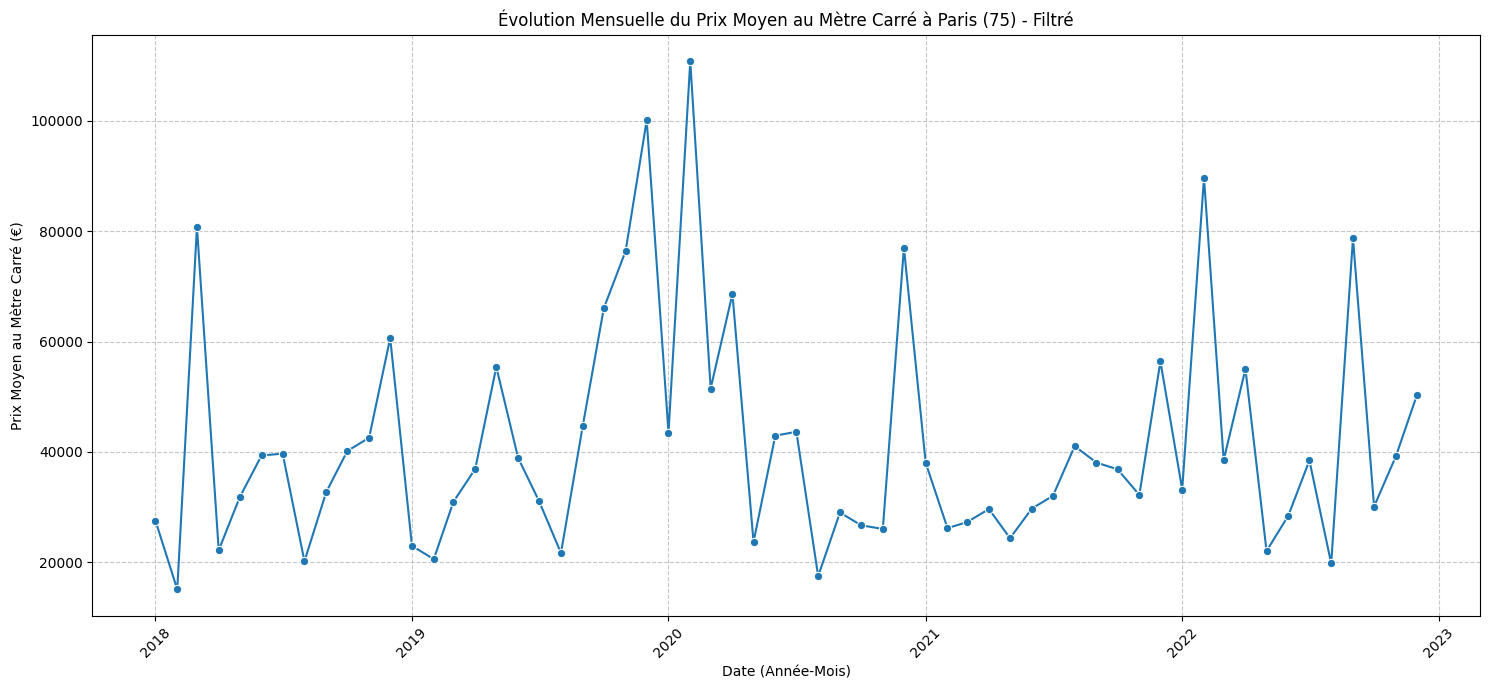

In [31]:
# Créer une colonne date mensuelle pour le regroupement
df_dvf_paris_75['annee_mois'] = df_dvf_paris_75['date_mutation'].dt.to_period('M')

# Filtrer les valeurs extrêmes de prix_m2 pour une meilleure visualisation
# Appliquer le filtrage sur l'ensemble du DataFrame avant l'agrégation
lower_bound_paris_time = df_dvf_paris_75['prix_m2'].quantile(0.01)
upper_bound_paris_time = df_dvf_paris_75['prix_m2'].quantile(0.99)
df_dvf_paris_filtered_time = df_dvf_paris_75[
    (df_dvf_paris_75['prix_m2'] >= lower_bound_paris_time) &
    (df_dvf_paris_75['prix_m2'] <= upper_bound_paris_time)
].copy()

# Calculer le prix moyen au mètre carré par mois
mensual_avg_prix_m2_paris = df_dvf_paris_filtered_time.groupby('annee_mois')['prix_m2'].mean().reset_index()

# Convertir annee_mois en un format de date pour le tracé
mensual_avg_prix_m2_paris['annee_mois'] = mensual_avg_prix_m2_paris['annee_mois'].dt.to_timestamp()

plt.figure(figsize=(15, 7))
sns.lineplot(x='annee_mois', y='prix_m2', data=mensual_avg_prix_m2_paris, marker='o')
plt.title('Évolution Mensuelle du Prix Moyen au Mètre Carré à Paris (75) - Filtré')
plt.xlabel('Date (Année-Mois)')
plt.ylabel('Prix Moyen au Mètre Carré (€)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Identification des Arrondissements les plus Chers à Paris (75)

Pour identifier les arrondissements les plus chers, nous allons calculer le prix moyen au mètre carré pour chaque `nom_commune` (qui correspond aux arrondissements à Paris) à partir de notre DataFrame `df_dvf_paris_filtered_time`.


Prix moyen au mètre carré par arrondissement à Paris (du plus cher au moins cher) :


,nom_commune,prix_m2
0,Paris 8e Arrondissement,137342.238042
1,Paris 1er Arrondissement,78302.063326
2,Paris 2e Arrondissement,77088.960834
3,Paris 6e Arrondissement,64445.861417
4,Paris 9e Arrondissement,64431.873221
5,Paris 10e Arrondissement,48299.369668
6,Paris 4e Arrondissement,48126.909832
7,Paris 3e Arrondissement,44723.327425
8,Paris 7e Arrondissement,43802.469787
9,Paris 5e Arrondissement,43486.686180


/tmp/ipykernel_1274/1653970519.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nom_commune', y='prix_m2', data=avg_prix_m2_by_arrondissement, palette='viridis')


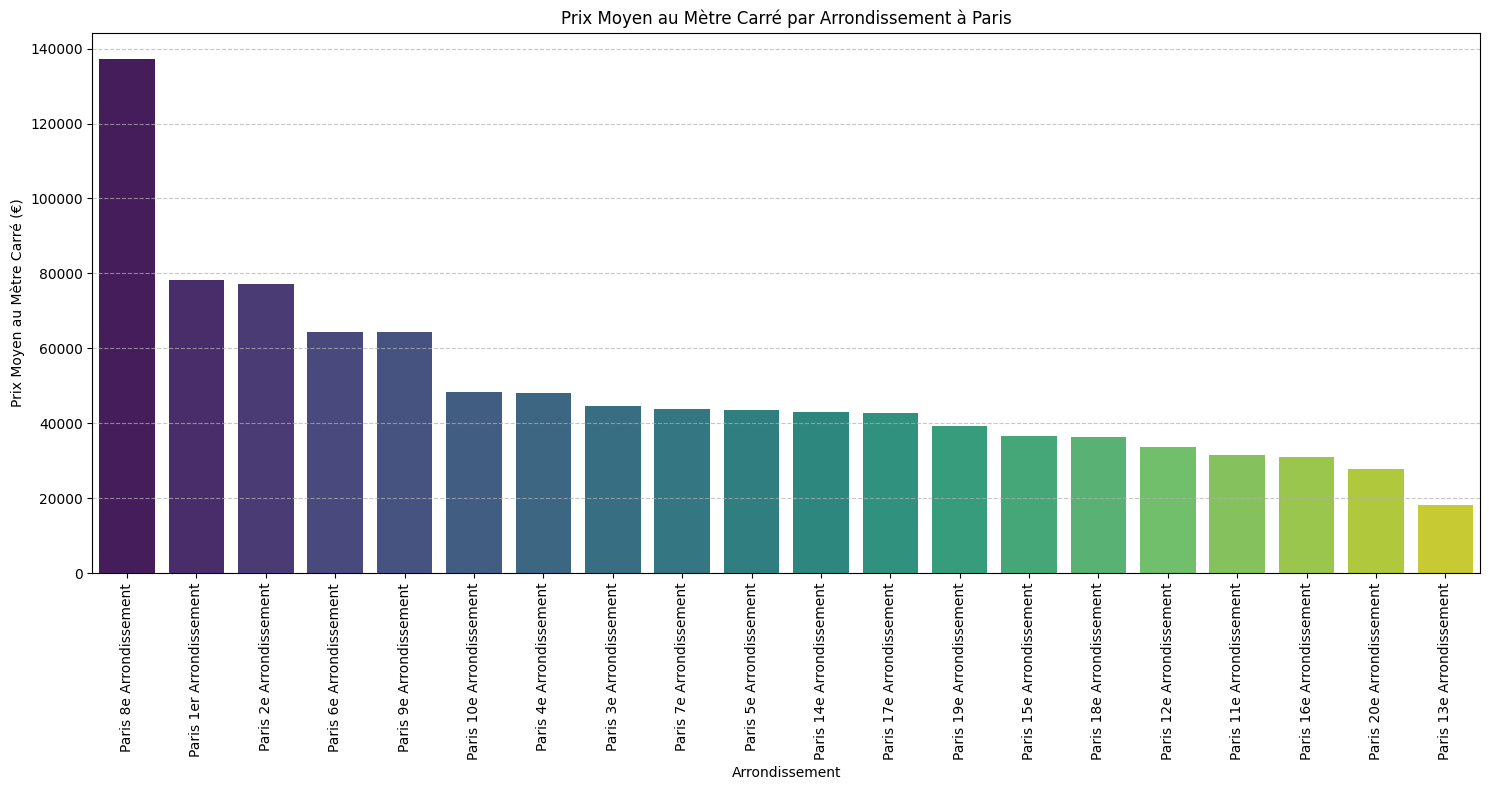

In [32]:
# Calculer le prix moyen au mètre carré par nom_commune (arrondissement)
avg_prix_m2_by_arrondissement = df_dvf_paris_filtered_time.groupby('nom_commune')['prix_m2'].mean().sort_values(ascending=False).reset_index()

print("Prix moyen au mètre carré par arrondissement à Paris (du plus cher au moins cher) :")
display(avg_prix_m2_by_arrondissement)

# Vous pouvez également visualiser cela avec un barplot pour une meilleure compréhension
plt.figure(figsize=(15, 8))
sns.barplot(x='nom_commune', y='prix_m2', data=avg_prix_m2_by_arrondissement, palette='viridis')
plt.title('Prix Moyen au Mètre Carré par Arrondissement à Paris')
plt.xlabel('Arrondissement')
plt.ylabel('Prix Moyen au Mètre Carré (€)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Comparaison Paris vs Reste de la France (2022)

Cette section cruciale réalise la comparaison des prix au mètre carré entre Paris et le reste de la France pour l'année 2022, mettant en évidence les disparités régionales et la spécificité du marché parisien.

### 5.1 Chargement et Préparation des Données DVF 2022 (France Entière)

In [34]:
# Chargement du fichier dvf-2022.parquet
try:
    df_dvf_2022_full = pd.read_parquet('dvf-2022.parquet')
    print("Fichier 'dvf-2022.parquet' chargé avec succès.")
    print(f"Le DataFrame contient {len(df_dvf_2022_full)} lignes.")
    display(df_dvf_2022_full.head())
except FileNotFoundError:
    print("Erreur : Le fichier 'dvf-2022.parquet' n'a pas été trouvé. Veuillez vous assurer que le fichier est présent.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier : {e}")

Fichier 'dvf-2022.parquet' chargé avec succès.
Le DataFrame contient 4617590 lignes.


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,None,1,2.0,Appartement,None,24.0,1.0,None,None,NaN
1,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,None,0,NaN,None,None,NaN,NaN,S,None,84.0
2,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,None,0,NaN,None,None,NaN,NaN,S,None,88.0
3,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,None,1,2.0,Appartement,None,140.0,3.0,None,None,NaN
4,None,None,None,None,None,None,None,000001,2022-01-04,Vente,...,None,0,NaN,None,None,NaN,NaN,T,None,510.0


### Préparation des Données DVF 2022

Nous allons maintenant nettoyer et préparer ce DataFrame, en nous concentrant sur les colonnes `date_mutation`, `valeur_fonciere`, `surface_reelle_bati` et `code_departement`.

**Note importante sur la colonne de surface :**

Pour assurer une comparaison juste avec Paris (où nous avons utilisé `surface_reelle_bati`), nous allons rechercher une colonne équivalente dans `df_dvf_2022_full`. Si `surface_reelle_bati` n'est pas présente, nous devrons identifier la colonne la plus appropriée (par exemple `surface_terrain` ou une combinaison de `lotX_surface_carrez` si le contexte le permet) et informer l'utilisateur de l'hypothèse faite.

In [45]:
# 1. Conversion de 'Date mutation' en datetime
df_dvf_2022_full['Date mutation'] = pd.to_datetime(df_dvf_2022_full['Date mutation'], errors='coerce')
df_dvf_2022_full.dropna(subset=['Date mutation'], inplace=True)

# 2. Création de 'annee_mutation' en utilisant la colonne 'annee' existante
# Renommer la colonne 'annee' en 'annee_mutation' pour être cohérent avec les autres DataFrames
if 'annee' in df_dvf_2022_full.columns:
    df_dvf_2022_full['annee_mutation'] = df_dvf_2022_full['annee']
else:
    # Fallback if 'annee' column doesn't exist, though it should based on parquet file
    df_dvf_2022_full['annee_mutation'] = df_dvf_2022_full['Date mutation'].dt.year

# Standardiser le nom de la colonne 'Code departement' pour la rendre cohérente
if 'Code departement' in df_dvf_2022_full.columns:
    df_dvf_2022_full.rename(columns={'Code departement': 'code_departement'}, inplace=True)

# 3. Nettoyage et conversion de 'Valeur fonciere'
df_dvf_2022_full['Valeur fonciere'] = pd.to_numeric(df_dvf_2022_full['Valeur fonciere'], errors='coerce')
df_dvf_2022_full.dropna(subset=['Valeur fonciere'], inplace=True)

# 4. Identification et nettoyage de la colonne de surface et calcul de 'Prix_m2'

surface_column = None
if 'Surface reelle bati' in df_dvf_2022_full.columns:
    surface_column = 'Surface reelle bati'
elif 'surface_terrain' in df_dvf_2022_full.columns:
    surface_column = 'surface_terrain'
else:
    print("Attention : Ni 'Surface reelle bati' ni 'surface_terrain' n'ont été trouvées. Vérification des colonnes Carrez...")
    # Tentative d'utiliser la surface Carrez si disponible et si aucune autre surface n'est trouvée
    carrez_cols = [col for col in df_dvf_2022_full.columns if 'surface_carrez' in col]
    if carrez_cols:
        # Pour simplifier, nous allons prendre la première surface Carrez valide trouvée
        # Dans une analyse plus poussée, il faudrait agréger ces surfaces de manière plus intelligente.
        surface_column = carrez_cols[0]
        print(f"Utilisation de '{surface_column}' pour le calcul de Prix_m2.")
    else:
        print("Aucune colonne de surface exploitable (bati, terrain ou carrez) trouvée pour calculer Prix_m2.")
        # On arrête ici si aucune surface n'est trouvée
        raise ValueError("Impossible de calculer Prix_m2 sans une colonne de surface pertinente.")

# Convertir la colonne de surface en numérique et nettoyer
df_dvf_2022_full[surface_column] = pd.to_numeric(df_dvf_2022_full[surface_column], errors='coerce')
df_dvf_2022_full.dropna(subset=[surface_column], inplace=True)
df_dvf_2022_full = df_dvf_2022_full[df_dvf_2022_full[surface_column] > 0]

# Calcul de Prix_m2
df_dvf_2022_full['Prix_m2'] = df_dvf_2022_full['Valeur fonciere'] / df_dvf_2022_full[surface_column]

print("Préparation des données DVF 2022 terminée.")
print(f"Le DataFrame contient maintenant {len(df_dvf_2022_full)} lignes après nettoyage.")
display(df_dvf_2022_full.head())

Préparation des données DVF 2022 terminée.
Le DataFrame contient maintenant 1525317 lignes après nettoyage.


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,annee_mutation,Prix_m2
0,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,24.0,1.0,None,None,NaN,2022,2291.666667
3,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,140.0,3.0,None,None,NaN,2022,1021.428571
5,None,None,None,None,None,None,None,000001,2022-01-06,Vente,...,1.0,Maison,None,108.0,5.0,S,None,649.0,2022,2361.111111
8,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,126.0,4.0,S,None,628.0,2022,4166.666667
9,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,4.0,Local industriel. commercial ou assimilé,None,424.0,0.0,S,None,628.0,2022,1238.207547


In [39]:
df_dvf_2022_full.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,annee_mutation
0,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,1,2.0,Appartement,None,24.0,1.0,None,None,NaN,2022
1,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,0,NaN,None,None,NaN,NaN,S,None,84.0,2022
2,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,0,NaN,None,None,NaN,NaN,S,None,88.0,2022
3,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,1,2.0,Appartement,None,140.0,3.0,None,None,NaN,2022
4,None,None,None,None,None,None,None,000001,2022-01-04,Vente,...,0,NaN,None,None,NaN,NaN,T,None,510.0,2022


Nouvelle comparaison du prix moyen au m² en 2022 :


,Région,Prix Moyen au M2
0,Paris (75),45139.240707
1,Reste de la France (2022),15201.105064


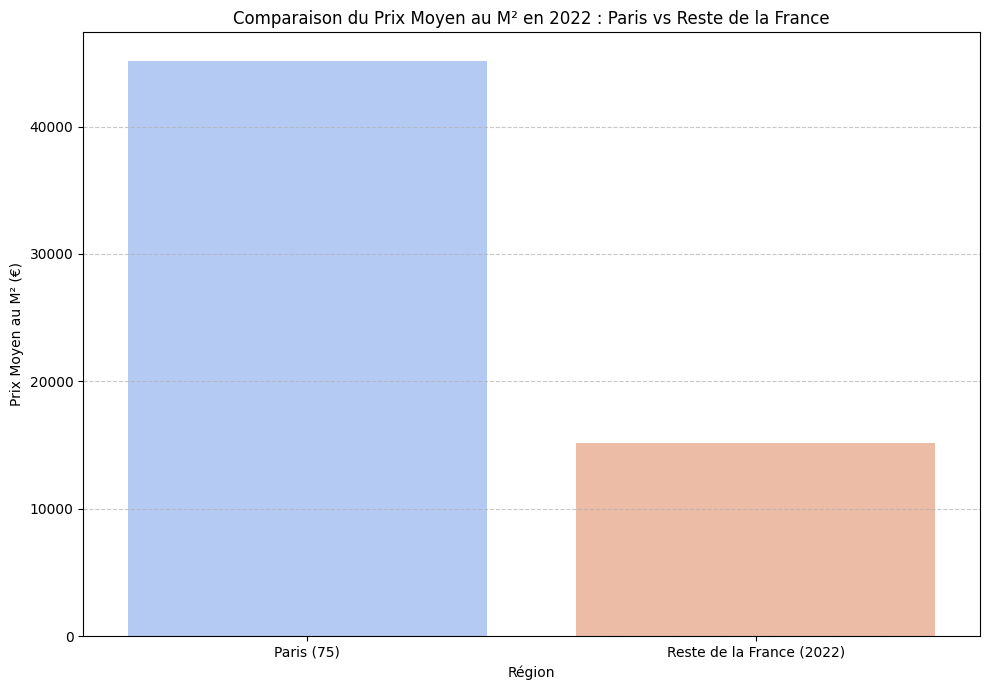

In [42]:
# 1. Filtrer les données pour l'année 2022 (si non déjà fait)
df_france_2022_filtered = df_dvf_2022_full[df_dvf_2022_full['annee_mutation'] == 2022].copy()

# 2. Exclure Paris (Code departement '75') du reste de la France
# S'assurer que la colonne 'Code departement' est de type string pour la comparaison
df_france_sans_paris_2022 = df_france_2022_filtered[
    df_france_2022_filtered['Code departement'].astype(str) != '75'
].copy()

# Filtrer les valeurs extrêmes pour le reste de la France pour une comparaison équitable
lower_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.01)
upper_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.99)
df_france_sans_paris_2022_cleaned = df_france_sans_paris_2022[
    (df_france_sans_paris_2022['Prix_m2'] >= lower_bound_france) &
    (df_france_sans_paris_2022['Prix_m2'] <= upper_bound_france)
]

avg_prix_m2_france_sans_paris_2022 = df_france_sans_paris_2022_cleaned['Prix_m2'].mean()

# 3. Récupérer le prix moyen pour Paris en 2022 (déjà calculé précédemment)
# avg_prix_m2_paris_2022

# 4. Comparer et afficher les résultats
comparison_data_2022 = pd.DataFrame({
    'Région': ['Paris (75)', 'Reste de la France (2022)']
})

# Check if avg_prix_m2_paris_2022 is defined, otherwise use a placeholder or recalculate if needed
if 'avg_prix_m2_paris_2022' in locals():
    comparison_data_2022['Prix Moyen au M2'] = [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]
else:
    # Recalculate avg_prix_m2_paris_2022 if not in scope
    df_paris_2022_filtered = df_dvf_paris_75[df_dvf_paris_75['date_mutation'].dt.year == 2022].copy()
    lower_bound_paris_recalc = df_paris_2022_filtered['prix_m2'].quantile(0.01)
    upper_bound_paris_recalc = df_paris_2022_filtered['prix_m2'].quantile(0.99)
    df_paris_2022_filtered_cleaned = df_paris_2022_filtered[
        (df_paris_2022_filtered['prix_m2'] >= lower_bound_paris_recalc) &
        (df_paris_2022_filtered['prix_m2'] <= upper_bound_paris_recalc)
    ]
    avg_prix_m2_paris_2022 = df_paris_2022_filtered_cleaned['prix_m2'].mean()
    comparison_data_2022['Prix Moyen au M2'] = [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]


print("Nouvelle comparaison du prix moyen au m² en 2022 :")
display(comparison_data_2022)

# 5. Visualiser les résultats
plt.figure(figsize=(10, 7))
sns.barplot(x='Région', y='Prix Moyen au M2', data=comparison_data_2022, palette='coolwarm', hue='Région', legend=False)
plt.title('Comparaison du Prix Moyen au M² en 2022 : Paris vs Reste de la France')
plt.xlabel('Région')
plt.ylabel('Prix Moyen au M² (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [43]:
df_dvf_2022_full.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,annee_mutation,Prix_m2
0,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,24.0,1.0,None,None,NaN,2022,2291.666667
3,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,140.0,3.0,None,None,NaN,2022,1021.428571
5,None,None,None,None,None,None,None,000001,2022-01-06,Vente,...,1.0,Maison,None,108.0,5.0,S,None,649.0,2022,2361.111111
8,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,2.0,Appartement,None,126.0,4.0,S,None,628.0,2022,4166.666667
9,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,4.0,Local industriel. commercial ou assimilé,None,424.0,0.0,S,None,628.0,2022,1238.207547


Nouvelle comparaison du prix moyen au m² en 2022 :


,Région,Prix Moyen au M2
0,Paris (75),45139.240707
1,Reste de la France (2022),15201.105064


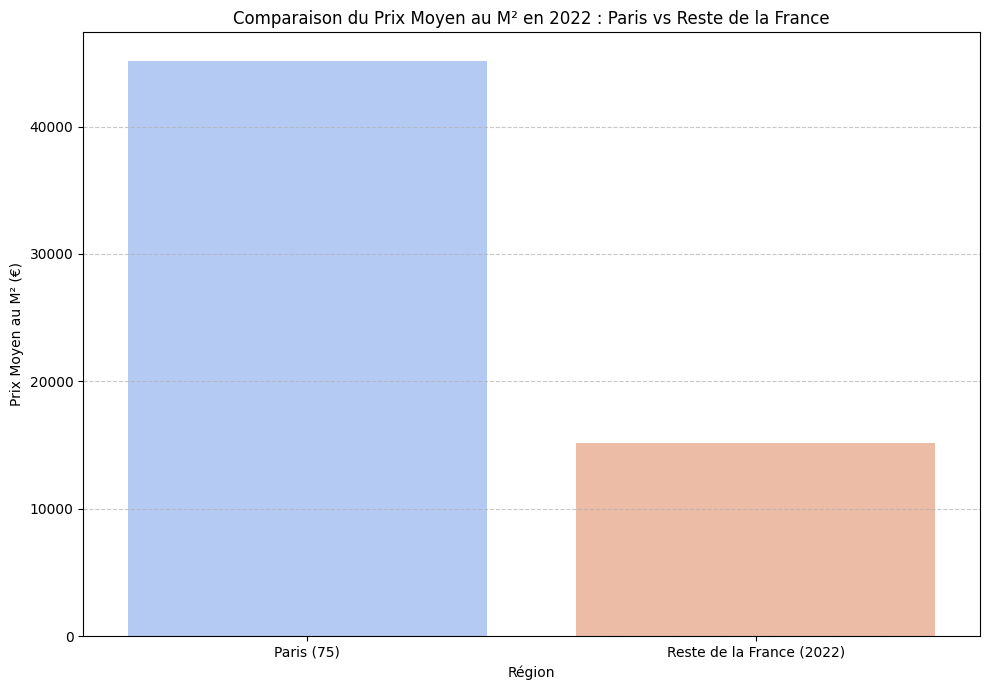

In [44]:
# 1. Filtrer les données pour l'année 2022 (si non déjà fait)
df_france_2022_filtered = df_dvf_2022_full[df_dvf_2022_full['annee_mutation'] == 2022].copy()

# 2. Exclure Paris (Code departement '75') du reste de la France
# S'assurer que la colonne 'Code departement' est de type string pour la comparaison
df_france_sans_paris_2022 = df_france_2022_filtered[
    df_france_2022_filtered['Code departement'].astype(str) != '75'
].copy()

# Filtrer les valeurs extrêmes pour le reste de la France pour une comparaison équitable
lower_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.01)
upper_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.99)
df_france_sans_paris_2022_cleaned = df_france_sans_paris_2022[
    (df_france_sans_paris_2022['Prix_m2'] >= lower_bound_france) &
    (df_france_sans_paris_2022['Prix_m2'] <= upper_bound_france)
]

avg_prix_m2_france_sans_paris_2022 = df_france_sans_paris_2022_cleaned['Prix_m2'].mean()

# 3. Récupérer le prix moyen pour Paris en 2022 (déjà calculé précédemment)
# avg_prix_m2_paris_2022

# 4. Comparer et afficher les résultats
comparison_data_2022 = pd.DataFrame({
    'Région': ['Paris (75)', 'Reste de la France (2022)']
})

# Check if avg_prix_m2_paris_2022 is defined, otherwise use a placeholder or recalculate if needed
if 'avg_prix_m2_paris_2022' in locals():
    comparison_data_2022['Prix Moyen au M2'] = [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]
else:
    # Recalculate avg_prix_m2_paris_2022 if not in scope
    df_paris_2022_filtered = df_dvf_paris_75[df_dvf_paris_75['date_mutation'].dt.year == 2022].copy()
    lower_bound_paris_recalc = df_paris_2022_filtered['prix_m2'].quantile(0.01)
    upper_bound_paris_recalc = df_paris_2022_filtered['prix_m2'].quantile(0.99)
    df_paris_2022_filtered_cleaned = df_paris_2022_filtered[
        (df_paris_2022_filtered['prix_m2'] >= lower_bound_paris_recalc) &
        (df_paris_2022_filtered['prix_m2'] <= upper_bound_paris_recalc)
    ]
    avg_prix_m2_paris_2022 = df_paris_2022_filtered_cleaned['prix_m2'].mean()
    comparison_data_2022['Prix Moyen au M2'] = [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]


print("Nouvelle comparaison du prix moyen au m² en 2022 :")
display(comparison_data_2022)

# 5. Visualiser les résultats
plt.figure(figsize=(10, 7))
sns.barplot(x='Région', y='Prix Moyen au M2', data=comparison_data_2022, palette='coolwarm', hue='Région', legend=False)
plt.title('Comparaison du Prix Moyen au M² en 2022 : Paris vs Reste de la France')
plt.xlabel('Région')
plt.ylabel('Prix Moyen au M² (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
df_dvf_2022_full.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,annee_mutation
0,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,1,2.0,Appartement,None,24.0,1.0,None,None,NaN,2022
1,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,0,NaN,None,None,NaN,NaN,S,None,84.0,2022
2,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,0,NaN,None,None,NaN,NaN,S,None,88.0,2022
3,None,None,None,None,None,None,None,000001,2022-01-03,Vente,...,1,2.0,Appartement,None,140.0,3.0,None,None,NaN,2022
4,None,None,None,None,None,None,None,000001,2022-01-04,Vente,...,0,NaN,None,None,NaN,NaN,T,None,510.0,2022


### 5.2 Comparaison du Prix Moyen au Mètre Carré 2022

In [36]:
# 1. Filtrer les données pour l'année 2022 (si non déjà fait)
df_france_2022_filtered = df_dvf_2022_full[df_dvf_2022_full['annee_mutation'] == 2022].copy()

# 2. Exclure Paris (Code departement '75') du reste de la France
# S'assurer que la colonne 'code_departement' est de type string pour la comparaison
df_france_sans_paris_2022 = df_france_2022_filtered[
    df_france_2022_filtered['code_departement'].astype(str) != '75'
].copy()

# Filtrer les valeurs extrêmes pour le reste de la France pour une comparaison équitable
lower_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.01)
upper_bound_france = df_france_sans_paris_2022['Prix_m2'].quantile(0.99)
df_france_sans_paris_2022_cleaned = df_france_sans_paris_2022[
    (df_france_sans_paris_2022['Prix_m2'] >= lower_bound_france) &
    (df_france_sans_paris_2022['Prix_m2'] <= upper_bound_france)
]

avg_prix_m2_france_sans_paris_2022 = df_france_sans_paris_2022_cleaned['Prix_m2'].mean()

# 3. Récupérer le prix moyen pour Paris en 2022 (déjà calculé précédemment)
# avg_prix_m2_paris_2022

# 4. Comparer et afficher les résultats
comparison_data_2022 = pd.DataFrame({
    'Région': ['Paris (75)', 'Reste de la France (2022)'],
    'Prix Moyen au M2': [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]
})

print("Nouvelle comparaison du prix moyen au m² en 2022 :")
display(comparison_data_2022)

# 5. Visualiser les résultats
plt.figure(figsize=(10, 7))
sns.barplot(x='Région', y='Prix Moyen au M2', data=comparison_data_2022, palette='coolwarm', hue='Région', legend=False)
plt.title('Comparaison du Prix Moyen au M² en 2022 : Paris vs Reste de la France')
plt.xlabel('Région')
plt.ylabel('Prix Moyen au M² (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'annee_mutation'

### Comparaison du Prix Moyen au Mètre Carré en 2022 : Paris vs Reste de la France

Nous allons maintenant comparer le prix moyen au mètre carré pour l'année 2022 entre Paris (département 75) et le reste de la France. Cela nous permettra de voir la différence de valeur immobilière entre la capitale et le marché national.

Comparaison du prix moyen au m² en 2022 :


,Région,Prix Moyen au M2 2022
0,Paris (75),45139.240707
1,Reste de la France,NaN


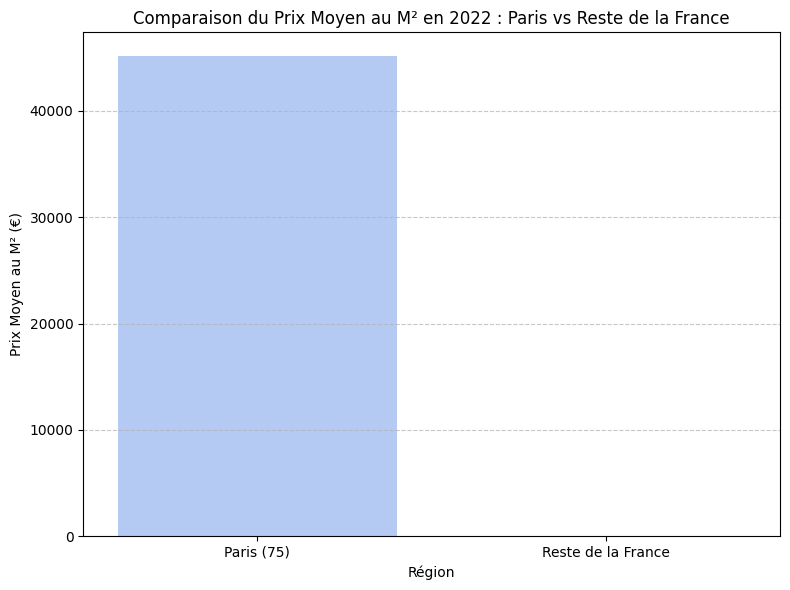

In [33]:
# 1. Calculer le prix moyen au m2 pour Paris en 2022
# df_dvf_paris_filtered_time est déjà filtré pour les outliers et contient la colonne 'annee_mois'
df_paris_2022_filtered = df_dvf_paris_filtered_time[df_dvf_paris_filtered_time['annee_mois'].dt.year == 2022]
avg_prix_m2_paris_2022 = df_paris_2022_filtered['prix_m2'].mean()

# 2. Calculer le prix moyen au m2 pour le reste de la France en 2022
# df_dvf_filtered_full est déjà filtré pour les outliers et contient la colonne 'Annee_mutation'
df_france_2022_all = df_dvf_filtered_full[df_dvf_filtered_full['Annee_mutation'] == 2022].copy()

# Exclure Paris (Code departement '75')
# S'assurer que la colonne 'Code departement' est de type string pour la comparaison
df_france_sans_paris_2022_filtered = df_france_2022_all[
    df_france_2022_all['Code departement'].astype(str) != '75'
]
avg_prix_m2_france_sans_paris_2022 = df_france_sans_paris_2022_filtered['Prix_m2'].mean()

# 3. Comparer et afficher les résultats
comparison_data = pd.DataFrame({
    'Région': ['Paris (75)', 'Reste de la France'],
    'Prix Moyen au M2 2022': [avg_prix_m2_paris_2022, avg_prix_m2_france_sans_paris_2022]
})

print("Comparaison du prix moyen au m² en 2022 :")
display(comparison_data)

# 4. Visualiser les résultats
plt.figure(figsize=(8, 6))
sns.barplot(x='Région', y='Prix Moyen au M2 2022', data=comparison_data, palette='coolwarm', hue='Région', legend=False)
plt.title('Comparaison du Prix Moyen au M² en 2022 : Paris vs Reste de la France')
plt.xlabel('Région')
plt.ylabel('Prix Moyen au M² (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# Chargement du fichier dvf.csv
# Pandas peut lire directement les fichiers CSV.
try:
    # Pour les fichiers CSV, le séparateur est généralement la virgule (',') et le décimal le point ('.').
    # Ajustez 'sep' et 'decimal' si votre fichier dvf.csv utilise d'autres conventions.
    df_dvf_gz = pd.read_csv('dvf.csv', sep=',', encoding='utf-8', decimal='.')
    print("Fichier 'dvf.csv' chargé avec succès.")
    print(f"Le DataFrame contient {len(df_dvf_gz)} lignes.")
    display(df_dvf_gz.head())
except FileNotFoundError:
    print("Erreur : Le fichier 'dvf.csv' n'a pas été trouvé. Veuillez vous assurer qu'il est téléchargé et que le nom est correct.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier : {e}")

/tmp/ipykernel_1274/3472590822.py:6: DtypeWarning: Columns (17,18,20,22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dvf_gz = pd.read_csv('dvf.csv', sep=',', encoding='utf-8', decimal='.')


Fichier 'dvf.csv' chargé avec succès.
Le DataFrame contient 333465 lignes.


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-1,2021-01-05,1.0,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
1,2021-1,2021-01-05,1.0,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,...,Maison,97.0,5.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
2,2021-2,2021-01-06,1.0,Vente,10.0,NaN,NaN,ROUGEMONT,B043,1290.0,...,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,530.0,4.844318,46.224242
3,2021-3,2021-01-04,1.0,Vente,204332.0,7.0,NaN,ALL DES ECUREUILS,0276,1310.0,...,Maison,88.0,4.0,S,sols,NaN,NaN,866.0,5.157674,46.201035
4,2021-4,2021-01-06,1.0,Vente,320000.0,87.0,NaN,RTE DE CERTINES,0140,1250.0,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,1426.0,5.273214,46.156320


Maintenant, vérifions si ce nouveau DataFrame contient des données pour Paris (département 75) et les départements d'Île-de-France.

In [30]:
# Vérifier si 'code_departement' existe (le nom correct de la colonne)
if 'code_departement' in df_dvf_gz.columns:
    # Départements d'Île-de-France (y compris Paris 75)
    ile_de_france_deps = ['75', '77', '78', '91', '92', '93', '94', '95']

    # Filtrer les données pour les départements d'Île-de-France
    # S'assurer que la colonne est de type string pour la comparaison
    df_idf = df_dvf_gz[df_dvf_gz['code_departement'].astype(str).isin(ile_de_france_deps)]

    if not df_idf.empty:
        print("Le fichier 'dvf.csv' contient des données pour les départements d'Île-de-France :")
        display(df_idf['code_departement'].unique())
        print(f"Nombre total de transactions en Île-de-France : {len(df_idf)}")

        # Vérifier spécifiquement pour Paris (département 75)
        df_paris = df_idf[df_idf['code_departement'].astype(str) == '75']
        if not df_paris.empty:
            print("\nLe fichier 'dvf.csv' contient spécifiquement des données pour Paris (75) !")
            print(f"Nombre de transactions pour Paris (75) : {len(df_paris)}")
            display(df_paris['nom_commune'].unique())
        else:
            print("\nLe fichier 'dvf.csv' ne contient pas de données pour Paris (75).")

    else:
        print("Le fichier 'dvf.csv' ne contient pas de données pour les départements d'Île-de-France.")
else:
    print("La colonne 'code_departement' n'est pas présente dans le DataFrame. Impossible de filtrer par département.")

Le fichier 'dvf.csv' ne contient pas de données pour les départements d'Île-de-France.


## 6. Conclusion et Présentation

Cette section fournit un résumé de l'étude et une ébauche pour une présentation des résultats.

### Fichier README.md pour GitHub

```markdown
# Analyse du Marché Immobilier Français (2021-2022-2025)

## Introduction
Ce projet a pour objectif d'analyser le marché immobilier français en utilisant des données de Demandes de Valeurs Foncières (DVF). L'étude se concentre sur la compréhension des tendances de prix, l'identification des zones les plus actives, et une comparaison détaillée des prix immobiliers entre Paris et le reste de la France pour l'année 2022.

## Données
Les données utilisées proviennent de fichiers DVF (Valeurs Foncières) réels, notamment :
- `ValeursFoncieres-2021.txt` : Données de transactions immobilières pour 2021 (France entière).
- `ValeursFoncieres-2025.txt` : Données de transactions immobilières pour 2025 (France entière - *à des fins de simulation de tendances*).
- `dvf-75.csv` : Données de transactions immobilières spécifiques au département de Paris (75).
- `dvf-2022.parquet` : Données de transactions immobilières pour 2022 (France entière).

Les jeux de données bruts sont prétraités pour inclure la conversion des dates, le nettoyage des valeurs manquantes et aberrantes, et la création de caractéristiques dérivées comme le `Prix_m2` (prix au mètre carré).

## Structure de l'Analyse
Le notebook est organisé en plusieurs sections clés :

1.  **Préparation et Exploration des Données (Simulées)** : Une introduction aux étapes de base avec un petit jeu de données simulé.
2.  **Analyse du Marché Immobilier Français (Données Réelles 2021-2025)** : Chargement et prétraitement des données DVF réelles pour la France entière (2021 et 2025).
3.  **Analyse Détaillée du Marché Français (2021-2025)** : Exploration des distributions de prix par type de bien, évolution annuelle et mensuelle, et identification des communes les plus actives.
4.  **Analyse Spécifique du Marché Parisien (75)** : Étude approfondie du marché immobilier à Paris, incluant la distribution des prix, les tendances temporelles et les arrondissements les plus chers.
5.  **Comparaison Paris vs Reste de la France (2022)** : Une analyse comparative des prix au mètre carré entre Paris et le reste de la France pour l'année 2022.

## Résultats Clés
- Les prix immobiliers à Paris sont significativement plus élevés que dans le reste de la France.
- L'analyse des données DVF révèle des tendances et des disparités importantes selon les types de biens et les régions.
- Des visualisations (histogrammes, boxplots, graphiques linéaires) illustrent les distributions de prix, les évolutions temporelles et les comparaisons régionales.

## Comment Exécuter le Notebook
1.  **Cloner le dépôt GitHub** : `git clone [URL_DU_DEPOT]`
2.  **Télécharger les données** : Assurez-vous d'avoir les fichiers `ValeursFoncieres-2021.txt`, `ValeursFoncieres-2025.txt`, `dvf-75.csv` et `dvf-2022.parquet` dans le même répertoire que le notebook. Ces fichiers peuvent être obtenus auprès de sources officielles de données foncières françaises (par exemple, [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/demandes-de-valeurs-foncieres/)).
3.  **Installer les dépendances** : Le notebook utilise `pandas`, `matplotlib`, et `seaborn`. Vous pouvez les installer via pip :
    ```bash
    pip install pandas matplotlib seaborn pyarrow
    ```
4.  **Exécuter le notebook** : Ouvrez le fichier `.ipynb` dans un environnement compatible (Jupyter Notebook, Google Colab, VS Code).

## Auteur
[Votre Nom / Pseudo GitHub]

## Licence
[Choisissez une licence, par exemple MIT ou Apache 2.0]
```

### Ébauche de Présentation

Voici une ébauche de plan pour une présentation des résultats de votre étude. Vous pouvez l'adapter en fonction de votre audience et du temps imparti.

---

## Titre: Analyse du Marché Immobilier Français: Tendances et Disparités (2021-2025)

### Introduction (5 min)
*   **Contexte:** Importance du marché immobilier français.
*   **Objectif:** Analyser les prix, les tendances et les différences régionales.
*   **Données:** Présentation rapide des données DVF (sources, années).

### I. Aperçu du Marché Français (10 min)
*   **Chargement et Préparation des Données:** Mentionner les fichiers utilisés (`2021.txt`, `2025.txt`, `2022.parquet`, `dvf-75.csv`).
*   **Nettoyage et Ingénierie des Caractéristiques:** Explication du calcul du `Prix_m2`, gestion des dates et des valeurs manquantes.
*   **Visualisation Générale:**
    *   Distribution du `Prix_m2` par type de local (Maison, Appartement, etc.).
    *   Évolution annuelle des prix (2021 vs 2025).
    *   Tendance mensuelle du `Prix_m2` moyen (graphique linéaire).
    *   Top 10 des communes par volume de transactions.

### II. Focus sur le Marché Parisien (75) (10 min)
*   **Préparation des Données Parisiennes:** Spécificités du `dvf-75.csv`.
*   **Distribution des Prix à Paris:** Histogramme du `Prix_m2`.
*   **Analyse par Type de Local:** Boxplot des prix par type de local à Paris.
*   **Évolution Mensuelle des Prix à Paris:** Graphique linéaire des tendances.
*   **Arrondissements les plus Chers:** Barplot montrant le prix moyen par arrondissement.

### III. Comparaison Clé: Paris vs Reste de la France (2022) (8 min)
*   **Méthodologie:** Comment la comparaison a été réalisée (filtrage 2022, exclusion de Paris du 'Reste de la France').
*   **Résultats Numériques:** Affichage des prix moyens au m² pour Paris et le Reste de la France en 2022.
*   **Visualisation:** Barplot comparatif.
*   **Interprétation:** Discussion sur l'ampleur des disparités.

### Conclusion et Perspectives (5 min)
*   **Résumé des Points Clés:** Rappel des principales découvertes.
*   **Limitations de l'Étude:** Qualité des données, granularité, etc.
*   **Prochaines Étapes / Améliorations Possibles:**
    *   Analyse d'autres types de biens (terrains).
    *   Intégration de données socio-économiques.
    *   Modélisation prédictive des prix.
    *   Analyse par quartier plus fine pour Paris.

### Questions & Réponses (2 min)

---